<a href="https://colab.research.google.com/github/miller00315/ia_studies/blob/main/ensamble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    make_scorer,
)

In [2]:
RANDOM_STATE = 7895

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/vqrca/ml-datasets/refs/heads/main/BankChurners_portugues.csv')

In [4]:
pd.set_option('display.max_columns', None)
print(df.head())

   Numero_Cliente Target  Idade_Cliente     Genero  Numero_Dependentes  \
0       768805383  Ativo             45  Masculino                   3   
1       818770008  Ativo             49   Feminino                   5   
2       713982108  Ativo             51  Masculino                   3   
3       769911858  Ativo             40   Feminino                   4   
4       709106358  Ativo             40  Masculino                   3   

              Escolaridade   Estado_Civil         Faixa_Renda_Anual  \
0             Ensino medio      Casado(a)   US$ 60 mil a US$ 80 mil   
1                Graduacao    Solteiro(a)       Menos de US$ 40 mil   
2                Graduacao      Casado(a)  US$ 80 mil a US$ 120 mil   
3             Ensino medio  Nao informado       Menos de US$ 40 mil   
4  Sem escolaridade formal      Casado(a)   US$ 60 mil a US$ 80 mil   

  Categoria_Cartao  Meses_Como_Cliente  Quantidade_Produtos_Banco  \
0             Azul                  39                     

In [5]:
df.shape

(10127, 21)

In [6]:
print(f'Número de clientes duplicados: {df["Numero_Cliente"].duplicated().sum()}')

Número de clientes duplicados: 0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Numero_Cliente                        10127 non-null  int64  
 1   Target                                10127 non-null  object 
 2   Idade_Cliente                         10127 non-null  int64  
 3   Genero                                10127 non-null  object 
 4   Numero_Dependentes                    10127 non-null  int64  
 5   Escolaridade                          10127 non-null  object 
 6   Estado_Civil                          10127 non-null  object 
 7   Faixa_Renda_Anual                     10127 non-null  object 
 8   Categoria_Cartao                      10127 non-null  object 
 9   Meses_Como_Cliente                    10127 non-null  int64  
 10  Quantidade_Produtos_Banco             10127 non-null  int64  
 11  Meses_Inativo_U

In [8]:
contagem_target = df['Target'].value_counts()
proporcao_target = df['Target'].value_counts(normalize=True).mul(100).round(2)

pd.DataFrame({
    'Quantidade': contagem_target,
    'Percentual (%)': proporcao_target
})


,Quantidade,Percentual (%)
Target,,
Ativo,8500,83.93
Inativo,1627,16.07


In [9]:
colunas_categoricas = [
    'Genero',
    'Escolaridade',
    'Estado_Civil',
    'Faixa_Renda_Anual',
    'Categoria_Cartao'
]

In [10]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(df[colunas_categoricas])
encoded_df = pd.DataFrame(encoded_data,
                          columns=encoder.get_feature_names_out(colunas_categoricas))

In [11]:
df_encoded = pd.concat([df.drop(columns=colunas_categoricas), encoded_df],
                       axis=1)


In [12]:
df_encoded.head()

,Numero_Cliente,Target,Idade_Cliente,Numero_Dependentes,Meses_Como_Cliente,Quantidade_Produtos_Banco,Meses_Inativo_Ultimos_12_Meses,Contatos_Ultimos_12_Meses,Limite_Credito,Saldo_Rotativo_Total,Credito_Disponivel_Medio,Variacao_Valor_Transacoes_T4_T1,Valor_Total_Transacoes,Quantidade_Total_Transacoes,Variacao_Quantidade_Transacoes_T4_T1,Taxa_Media_Utilizacao_Credito,Genero_Feminino,Genero_Masculino,Escolaridade_Doutorado,Escolaridade_Ensino medio,Escolaridade_Ensino superior incompleto,Escolaridade_Graduacao,Escolaridade_Nao informado,Escolaridade_Pos-graduacao,Escolaridade_Sem escolaridade formal,Estado_Civil_Casado(a),Estado_Civil_Divorciado(a),Estado_Civil_Nao informado,Estado_Civil_Solteiro(a),Faixa_Renda_Anual_Acima de US$ 120 mil,Faixa_Renda_Anual_Menos de US$ 40 mil,Faixa_Renda_Anual_Nao informado,Faixa_Renda_Anual_US$ 40 mil a US$ 60 mil,Faixa_Renda_Anual_US$ 60 mil a US$ 80 mil,Faixa_Renda_Anual_US$ 80 mil a US$ 120 mil,Categoria_Cartao_Azul,Categoria_Cartao_Ouro,Categoria_Cartao_Platina,Categoria_Cartao_Prata
0,768805383,Ativo,45,3,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,818770008,Ativo,49,5,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,713982108,Ativo,51,3,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,769911858,Ativo,40,4,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,709106358,Ativo,40,3,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [13]:
X = df_encoded.drop(['Numero_Cliente', 'Target'], axis=1)
y = df_encoded['Target']

print(f'Formato de X: {X.shape}')
print(f'Formato de y: {y.shape}')

Formato de X: (10127, 37)
Formato de y: (10127,)


In [14]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Treino: {X_treino.shape[0]} registros')
print(f'Teste:  {X_teste.shape[0]} registros')

Treino: 8101 registros
Teste:  2026 registros


In [15]:
pd.DataFrame({
    'Treino': y_treino.value_counts(normalize=True),
    'Teste':  y_teste.value_counts(normalize=True)
}).round(2)

,Treino,Teste
Target,,
Ativo,0.84,0.84
Inativo,0.16,0.16


In [16]:
modelo_arvore = DecisionTreeClassifier(random_state=RANDOM_STATE)

In [18]:
modelo_arvore.fit(X_treino, y_treino)

DecisionTreeClassifier(random_state=7895)

In [19]:
predicoes = modelo_arvore.predict(X_teste)

In [20]:
predicoes_treino = modelo_arvore.predict(X_treino)

acuracia_treino = accuracy_score(y_treino, predicoes_treino)
acuracia_teste  = accuracy_score(y_teste, predicoes)

print(f'Acurácia no treino: {acuracia_treino:.2%}')
print(f'Acurácia no teste:  {acuracia_teste:.2%}')

Acurácia no treino: 100.00%
Acurácia no teste:  92.89%


In [21]:
relatorio = classification_report(y_teste, predicoes)
print(relatorio)


              precision    recall  f1-score   support

       Ativo       0.96      0.96      0.96      1701
     Inativo       0.79      0.77      0.78       325

    accuracy                           0.93      2026
   macro avg       0.87      0.86      0.87      2026
weighted avg       0.93      0.93      0.93      2026



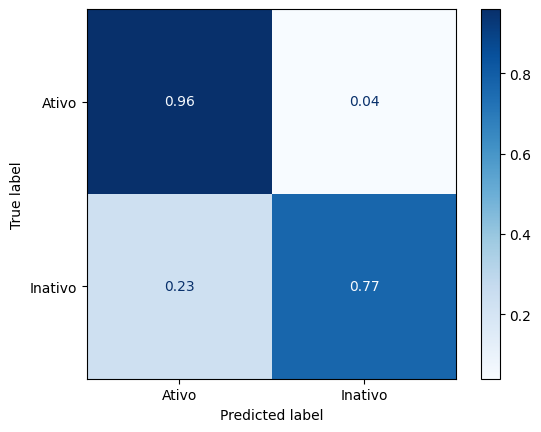

In [22]:
ConfusionMatrixDisplay.from_estimator(
    modelo_arvore, X_teste, y_teste,
    normalize='true', cmap='Blues'
);


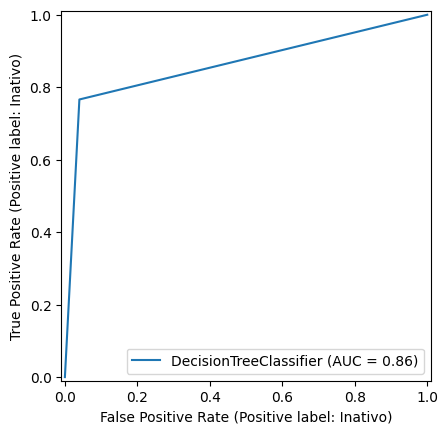

In [24]:
RocCurveDisplay.from_estimator(
    modelo_arvore, X_teste, y_teste,
    pos_label='Inativo'
);


In [25]:
modelo_rf = RandomForestClassifier(random_state=RANDOM_STATE)

In [26]:
modelo_rf.fit(X_treino, y_treino)

RandomForestClassifier(random_state=7895)

In [27]:
predicoes_rf = modelo_rf.predict(X_teste)

In [28]:
predicoes_rf_treino = modelo_rf.predict(X_treino)

acuracia_rf_treino = accuracy_score(y_treino, predicoes_rf_treino)
acuracia_rf_teste  = accuracy_score(y_teste, predicoes_rf)

print(f'Acurácia no treino - Random Forest: {acuracia_rf_treino:.2%}')
print(f'Acurácia no teste - Random Forest:  {acuracia_rf_teste:.2%}')

Acurácia no treino - Random Forest: 100.00%
Acurácia no teste - Random Forest:  95.71%


In [29]:
relatorio_rf = classification_report(y_teste, predicoes_rf)
print(relatorio_rf)

              precision    recall  f1-score   support

       Ativo       0.96      0.99      0.97      1701
     Inativo       0.95      0.77      0.85       325

    accuracy                           0.96      2026
   macro avg       0.96      0.88      0.91      2026
weighted avg       0.96      0.96      0.96      2026



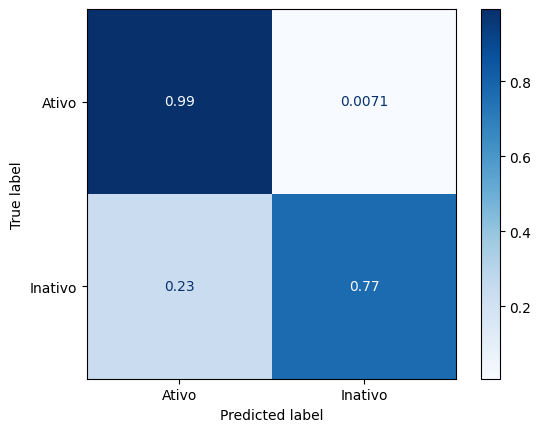

In [30]:
ConfusionMatrixDisplay.from_estimator(
    modelo_rf, X_teste, y_teste,
    normalize='true', cmap='Blues'
);

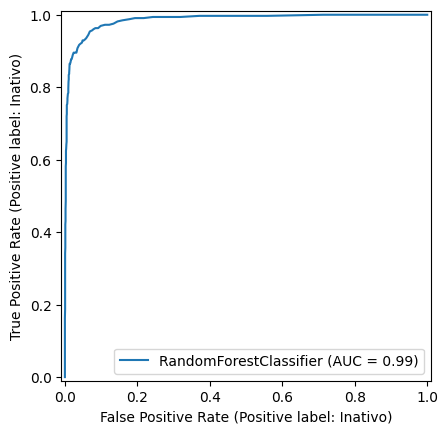

In [31]:
RocCurveDisplay.from_estimator(
    modelo_rf, X_teste, y_teste,
    pos_label='Inativo'
);


In [32]:
modelo_rf_500 = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=500)

In [33]:
modelo_rf_500.fit(X_treino, y_treino)

RandomForestClassifier(n_estimators=500, random_state=7895)

In [34]:
predicoes_rf_500 = modelo_rf_500.predict(X_teste)

In [35]:
relatorio_rf_500 = classification_report(y_teste, predicoes_rf_500)
print(relatorio_rf_500)

              precision    recall  f1-score   support

       Ativo       0.96      0.99      0.98      1701
     Inativo       0.96      0.79      0.87       325

    accuracy                           0.96      2026
   macro avg       0.96      0.89      0.92      2026
weighted avg       0.96      0.96      0.96      2026



In [36]:
scorer_recall = make_scorer(recall_score, pos_label='Inativo')

grade_parametros = {
    'n_estimators': [200, 500],
    'max_depth': [None, 15],
    'criterion': ['gini', 'entropy'],
}

modelo_rf_ajuste = RandomForestClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=modelo_rf_ajuste,
    param_grid=grade_parametros,
    cv=5,
    scoring=scorer_recall,          # ← usa o scorer com pos_label
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Recall médio (validação cruzada): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Melhores parâmetros encontrados: {'criterion': 'entropy', 'max_depth': None, 'n_estimators': 500}
Recall médio (validação cruzada): 0.6587


In [37]:
colunas_resultado = [
    'param_max_depth',
    'param_criterion',
    'param_n_estimators',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

resultados_cv = (
    pd.DataFrame(grid_search.cv_results_)[colunas_resultado]
    .sort_values('rank_test_score')
    .reset_index(drop=True)
)

resultados_cv


,param_max_depth,param_criterion,param_n_estimators,mean_test_score,std_test_score,rank_test_score
0,None,entropy,500,0.658671,0.308642,1
1,None,gini,500,0.653140,0.299434,2
2,None,entropy,200,0.651296,0.310013,3
3,None,gini,200,0.649459,0.298864,4
4,15,gini,500,0.649442,0.299078,5
5,15,entropy,500,0.643915,0.304010,6
6,15,gini,200,0.641463,0.293794,7
7,15,entropy,200,0.639611,0.302693,8


In [38]:
grid_search.best_estimator_

RandomForestClassifier(criterion='entropy', n_estimators=500, random_state=7895)

In [39]:
modelo_rf_ajustado = clone(grid_search.best_estimator_)
modelo_rf_ajustado.fit(X_treino, y_treino)

predicoes_rf_ajustado = modelo_rf_ajustado.predict(X_teste)

In [40]:
predicoes_rf_treino_ajustado = modelo_rf_ajustado.predict(X_treino)

acuracia_rf_treino_ajustado = accuracy_score(y_treino, predicoes_rf_treino_ajustado)
acuracia_rf_teste_ajustado  = accuracy_score(y_teste, predicoes_rf_ajustado)

print(f'Acurácia no treino: {acuracia_rf_treino_ajustado:.2%}')
print(f'Acurácia no teste:  {acuracia_rf_teste_ajustado:.2%}')


Acurácia no treino: 100.00%
Acurácia no teste:  96.00%


In [41]:
print(classification_report(y_teste, predicoes_rf_ajustado))

              precision    recall  f1-score   support

       Ativo       0.96      0.99      0.98      1701
     Inativo       0.96      0.79      0.86       325

    accuracy                           0.96      2026
   macro avg       0.96      0.89      0.92      2026
weighted avg       0.96      0.96      0.96      2026



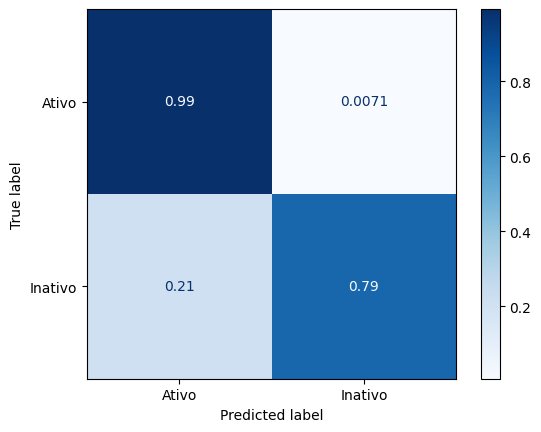

In [42]:
ConfusionMatrixDisplay.from_estimator(
    modelo_rf_ajustado, X_teste, y_teste,
    normalize='true', cmap='Blues'
);


In [43]:
importancias = pd.Series(
    modelo_rf_ajustado.feature_importances_,
    index=X_treino.columns
).sort_values(ascending=False)

importancias

,0
Valor_Total_Transacoes,0.189153
Quantidade_Total_Transacoes,0.164902
Saldo_Rotativo_Total,0.103149
Variacao_Quantidade_Transacoes_T4_T1,0.096093
Variacao_Valor_Transacoes_T4_T1,0.064840
Taxa_Media_Utilizacao_Credito,0.061444
Quantidade_Produtos_Banco,0.054758
Limite_Credito,0.036853
Credito_Disponivel_Medio,0.036339
Idade_Cliente,0.032778


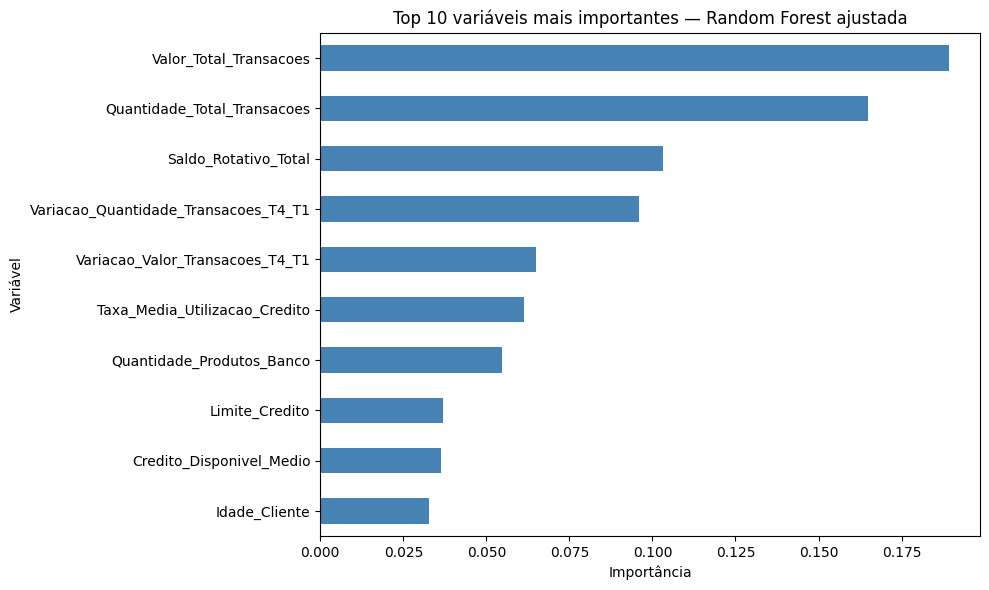

In [44]:
top_10 = importancias.head(10).sort_values()

plt.figure(figsize=(10, 6))
top_10.plot(kind='barh', color='steelblue')

plt.title('Top 10 variáveis mais importantes — Random Forest ajustada')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

In [45]:
top10_features = importancias.head(10).index.tolist()
print('Top 10 features selecionadas:')
for i, feat in enumerate(top10_features, start=1):
    print(f'  {i:2d}. {feat}')

Top 10 features selecionadas:
   1. Valor_Total_Transacoes
   2. Quantidade_Total_Transacoes
   3. Saldo_Rotativo_Total
   4. Variacao_Quantidade_Transacoes_T4_T1
   5. Variacao_Valor_Transacoes_T4_T1
   6. Taxa_Media_Utilizacao_Credito
   7. Quantidade_Produtos_Banco
   8. Limite_Credito
   9. Credito_Disponivel_Medio
  10. Idade_Cliente


In [46]:
X_treino_top10 = X_treino[top10_features]
X_teste_top10  = X_teste[top10_features]

print(f'\nFormato após seleção: treino {X_treino_top10.shape},teste {X_teste_top10.shape}')


Formato após seleção: treino (8101, 10),teste (2026, 10)


In [47]:
modelo_rf_fs = clone(grid_search.best_estimator_)

In [48]:
modelo_rf_fs.fit(X_treino_top10, y_treino)

RandomForestClassifier(criterion='entropy', n_estimators=500, random_state=7895)

In [50]:
predicoes_rf_fs = modelo_rf_fs.predict(X_teste_top10)

In [51]:
predicoes_rf_fs_treino = modelo_rf_fs.predict(X_treino_top10)

acuracia_fs_treino = accuracy_score(y_treino, predicoes_rf_fs_treino)
acuracia_fs_teste  = accuracy_score(y_teste, predicoes_rf_fs)

print(f'Acurácia no treino (top 10): {acuracia_fs_treino:.2%}')
print(f'Acurácia no teste  (top 10): {acuracia_fs_teste:.2%}')

Acurácia no treino (top 10): 100.00%
Acurácia no teste  (top 10): 96.35%


In [52]:
print(classification_report(y_teste, predicoes_rf_fs))

              precision    recall  f1-score   support

       Ativo       0.97      0.99      0.98      1701
     Inativo       0.93      0.83      0.88       325

    accuracy                           0.96      2026
   macro avg       0.95      0.91      0.93      2026
weighted avg       0.96      0.96      0.96      2026



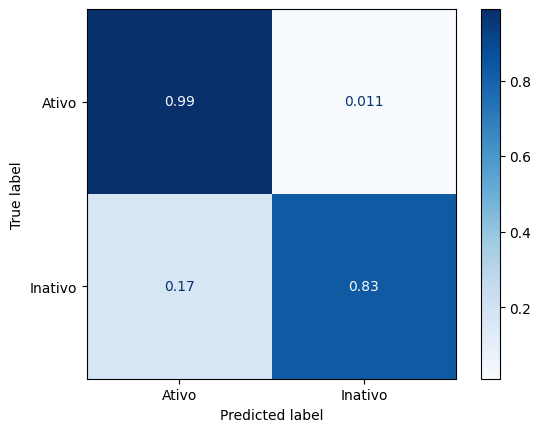

In [53]:
ConfusionMatrixDisplay.from_estimator(
    modelo_rf_fs, X_teste_top10, y_teste,
    normalize='true', cmap='Blues'
);


In [54]:
avaliacoes = {
    'Decision Tree': {
        'modelo': modelo_arvore,
        'X_teste': X_teste,
    },
    'Random Forest': {
        'modelo': modelo_rf,
        'X_teste': X_teste,
    },
    'Random Forest ajustado': {
        'modelo': modelo_rf_ajustado,
        'X_teste': X_teste,
    },
    'Random Forest ajustado + Feature Selection': {
        'modelo': modelo_rf_fs,
        'X_teste': X_teste_top10,   # ← conjunto reduzido, específico deste modelo
    },
}

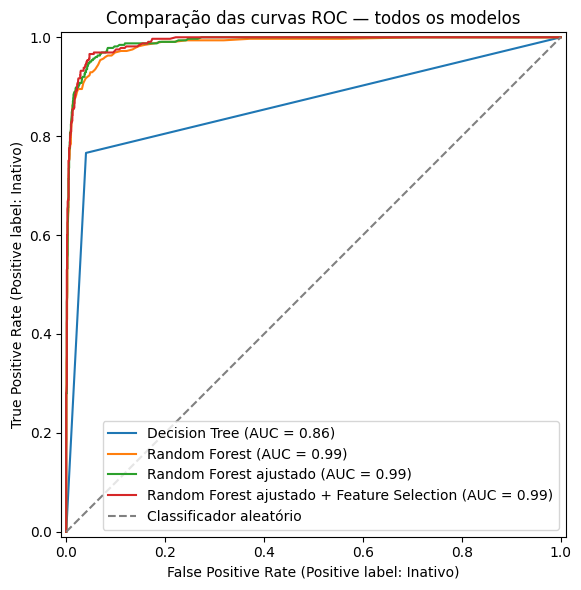

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))

for nome, info in avaliacoes.items():
    RocCurveDisplay.from_estimator(
        info['modelo'],
        info['X_teste'],
        y_teste,
        name=nome,
        pos_label='Inativo',
        ax=ax
    )

ax.plot([0, 1], [0, 1], '--', color='grey', label='Classificador aleatório')
ax.set_title('Comparação das curvas ROC — todos os modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


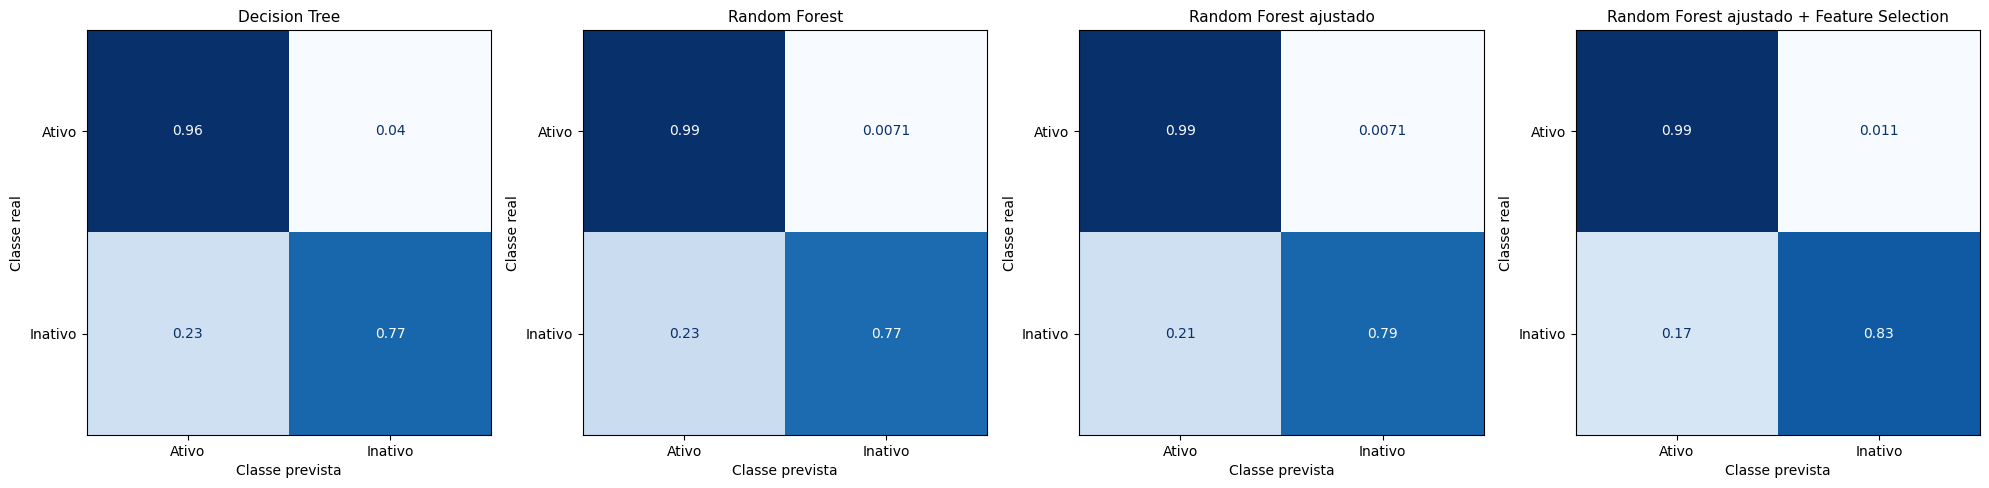

In [56]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (nome, info) in zip(axes, avaliacoes.items()):
    ConfusionMatrixDisplay.from_estimator(
        info['modelo'],
        info['X_teste'],
        y_teste,
        display_labels=info['modelo'].classes_,
        normalize='true',
        cmap='Blues',
        ax=ax,
        colorbar=False
    )
    ax.set_title(nome, fontsize=11)
    ax.set_xlabel('Classe prevista')
    ax.set_ylabel('Classe real')

plt.tight_layout()
plt.show()

In [57]:
resultados = []

for nome, info in avaliacoes.items():
    modelo = info['modelo']
    X_avaliar = info['X_teste']

    y_pred = modelo.predict(X_avaliar)
    y_prob = modelo.predict_proba(X_avaliar)[:, list(modelo.classes_).index('Inativo')]

    resultados.append({
        'Modelo': nome,
        'Accuracy':  accuracy_score(y_teste, y_pred),
        'Precision': precision_score(y_teste, y_pred, pos_label='Inativo'),
        'Recall':    recall_score(y_teste, y_pred, pos_label='Inativo'),
        'F1':        f1_score(y_teste, y_pred, pos_label='Inativo'),
        'ROC AUC':   roc_auc_score(y_teste == 'Inativo', y_prob),
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo').round(3)
df_resultados

,Accuracy,Precision,Recall,F1,ROC AUC
Modelo,,,,,
Decision Tree,0.929,0.785,0.766,0.776,0.863
Random Forest,0.957,0.954,0.769,0.852,0.986
Random Forest ajustado,0.960,0.955,0.788,0.863,0.990
Random Forest ajustado + Feature Selection,0.963,0.934,0.831,0.879,0.990
